## 1. Install

In [1]:
!pip install -q ultralytics roboflow pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 6.8 MB/s eta 0:00:00


## 2. Imports

In [2]:
import os, glob, yaml, shutil
from collections import Counter, defaultdict
from getpass import getpass
import matplotlib.pyplot as plt
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


## 3. Roboflow login

In [3]:
!pip install roboflow

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="BNfDOqRsxGI0IHhQuV6q")
project = rf.workspace("noora-5nyhs").project("trash-ucvyl")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Trash-1 in yolo26:: 100%|██████████| 5534/5534 [00:16<00:00, 336.24it/s] 


## 4. Download

In [5]:
DATASET_DIR = dataset.location
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
print(DATASET_DIR)

/content/Trash-1


## 5. Check classes

In [6]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

['cigarette', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'trash heap', 'vinyl']


## 6. Dataset counts

In [7]:
for split in ["train", "valid", "test"]:
    print(split, ":", len(glob.glob(f"{DATASET_DIR}/{split}/images/*")))

train : 1985
valid : 514
test : 266


## 7. Object counts


In [8]:
def names_list(names):
    if isinstance(names, dict):
        return [names.get(i, names.get(str(i))) for i in range(len(names))]
    return list(names)

class_list = names_list(class_names)
class_counts = Counter()
images_per_class = defaultdict(set)
total_images = 0

for split in ["train", "valid", "test"]:
    total_images += len(glob.glob(f"{DATASET_DIR}/{split}/images/*"))

    for label_file in glob.glob(f"{DATASET_DIR}/{split}/labels/*.txt"):
        seen = set()

        for line in open(label_file):
            parts = line.split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[cid] += 1
            seen.add(cid)

        for cid in seen:
            images_per_class[cid].add(label_file)

total_objects = sum(class_counts.values())

print("Total images:", total_images)
print("Total objects:", total_objects)
print("Average objects/image:", round(total_objects / total_images, 2))

for i, name in enumerate(class_list):
    print(f"{name}: {class_counts[i]} objects | {len(images_per_class[i])} images")

Total images: 2765
Total objects: 5026
Average objects/image: 1.82
cigarette: 123 objects | 33 images
clothes: 169 objects | 155 images
glass: 569 objects | 300 images
metal: 573 objects | 332 images
paper: 1195 objects | 594 images
plastic: 1270 objects | 839 images
trash heap: 207 objects | 186 images
vinyl: 920 objects | 595 images


## 8. Class chart

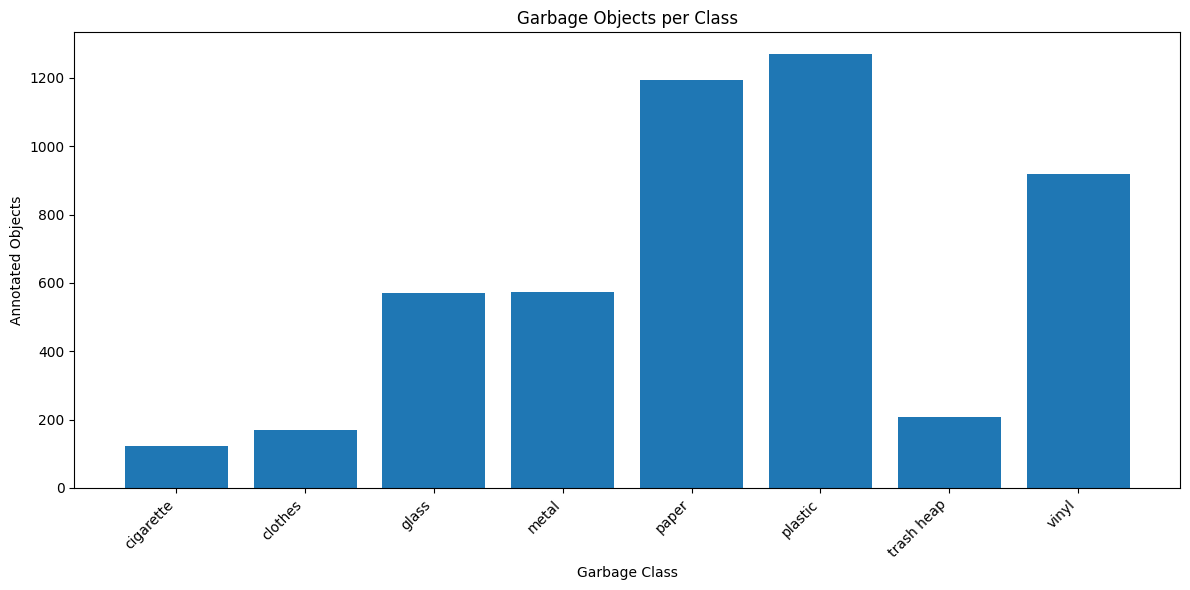

In [9]:
counts = [class_counts[i] for i in range(len(class_list))]

plt.figure(figsize=(12, 6))
plt.bar(class_list, counts)
plt.xlabel("Garbage Class")
plt.ylabel("Annotated Objects")
plt.title("Garbage Objects per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Baseline


image 1/1 /content/Trash-1/test/images/15493770_1200278826687624_9029517768223238409_o_jpg.rf.206eba19e65d00710d793139abc0e1ce.jpg: 640x640 13 persons, 2 backpacks, 50.8ms
Speed: 80.0ms preprocess, 50.8ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


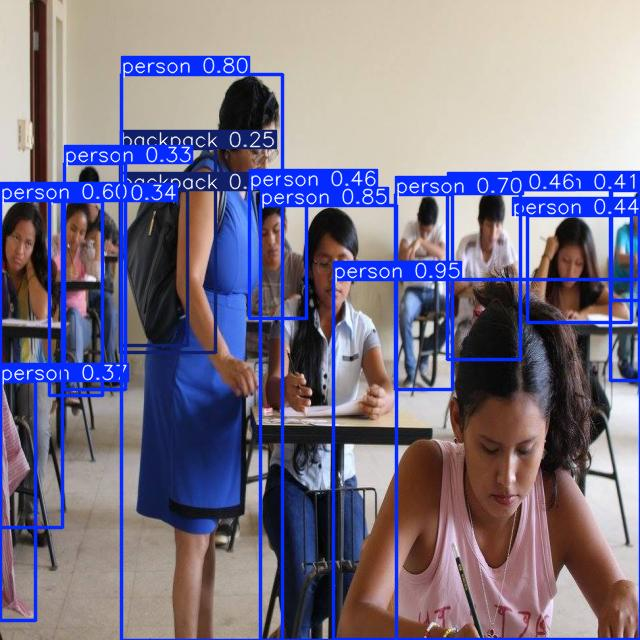

In [10]:

model = YOLO("yolo26n.pt")

test_images = glob.glob(f"{DATASET_DIR}/test/images/*")
if not test_images:
    raise ValueError("No test images found.")

baseline = model(test_images[0])
baseline[0].show()


## 10. Train with early stopping

In [11]:
yaml_path = '/content/Trash-1/data.yaml'


shutil.rmtree('/content/runs/garbage_detection/v1', ignore_errors=True)

model = YOLO("yolo26n.pt")

model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,
    cache=True,
    project="/content/runs/garbage_detection",
    name="v1"
)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Trash-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1, nbs=64, nms=False, opset=None, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d23b90cb3f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

## 11. Load best model

In [12]:
best_path = "/content/runs/garbage_detection/v1/weights/best.pt"
v1_model = YOLO(best_path)
print(v1_model.names)

{0: 'cigarette', 1: 'clothes', 2: 'glass', 3: 'metal', 4: 'paper', 5: 'plastic', 6: 'trash heap', 7: 'vinyl'}


## 12. Evaluate

In [13]:
metrics = v1_model.val(data=yaml_path, split="test")

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))


Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 88.9±56.9 MB/s, size: 453.7 KB)
val: Scanning /content/Trash-1/test/labels... 266 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 266/266 449.2it/s 0.6s
val: New cache created: /content/Trash-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.6it/s 10.5s
                   all        266        476      0.668      0.344      0.381      0.268
             cigarette          5         22          1          0          0          0
               clothes         14         14      0.578      0.571      0.678      0.499
                 glass         28         48      0.579      0.316      0.326      0.267
                 metal         26         39      0.583      0.282      0.296     

## 13. Per-class mAP50-95

In [ ]:
for name, score in zip(v1_model.names.values(), metrics.box.maps):
    print(name, ":", round(float(score), 4))


## 14. Test images


0: 640x640 (no detections), 4.8ms
1: 640x640 4 vinyls, 4.8ms
2: 640x640 (no detections), 4.8ms
3: 640x640 1 plastic, 4.8ms
4: 640x640 2 glasss, 4.8ms
5: 640x640 1 paper, 4.8ms
6: 640x640 2 vinyls, 4.8ms
7: 640x640 2 papers, 4.8ms
8: 640x640 1 paper, 1 plastic, 4.8ms
9: 640x640 1 vinyl, 4.8ms
Speed: 3.0ms preprocess, 4.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


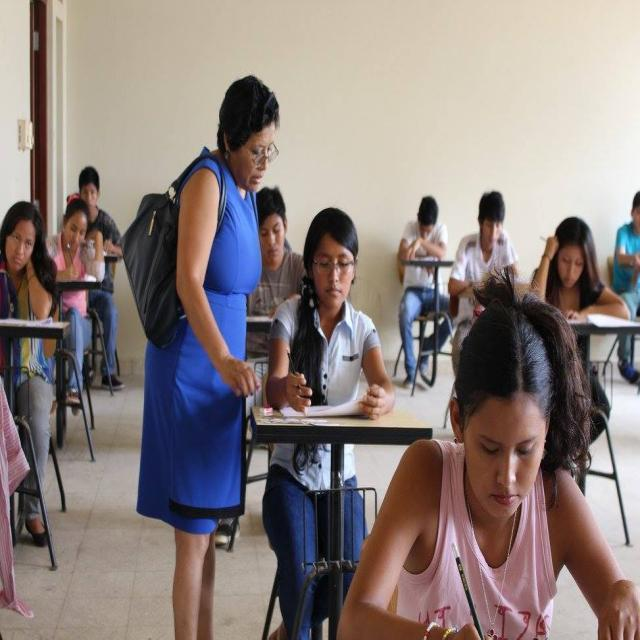

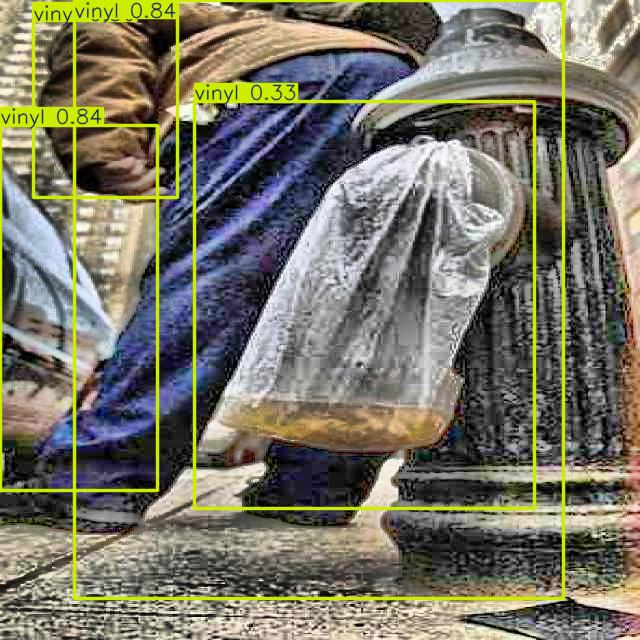

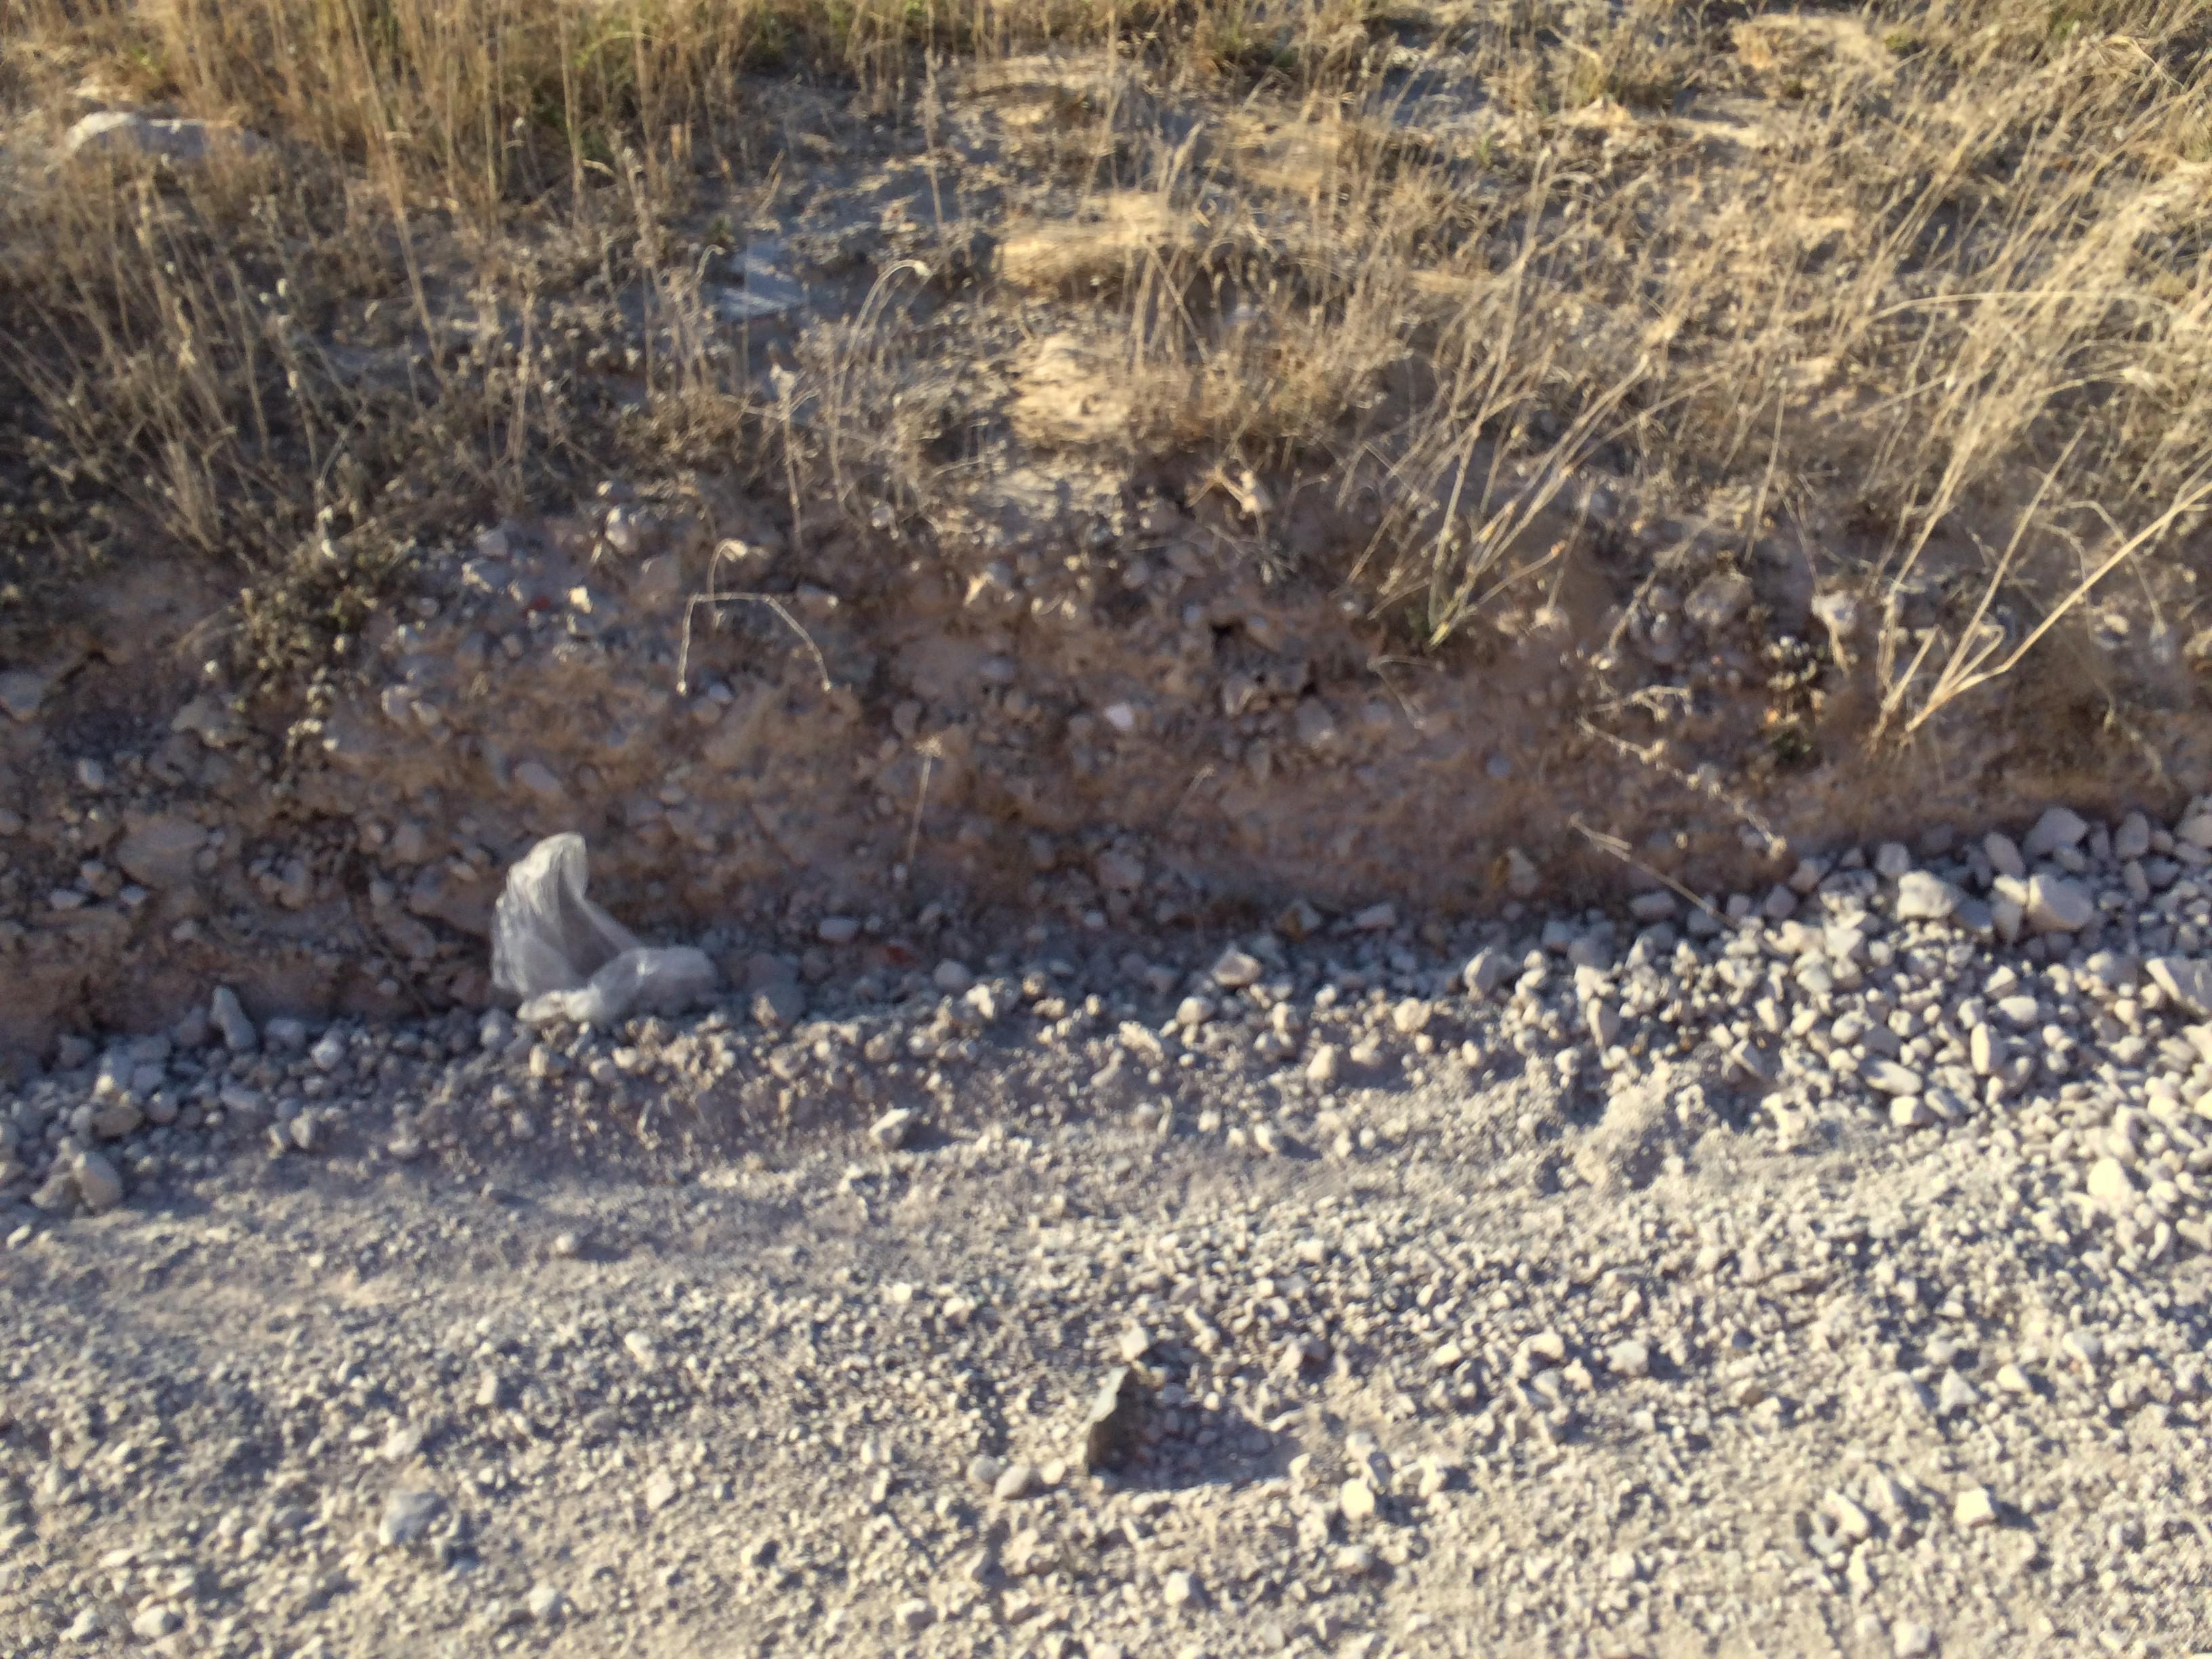

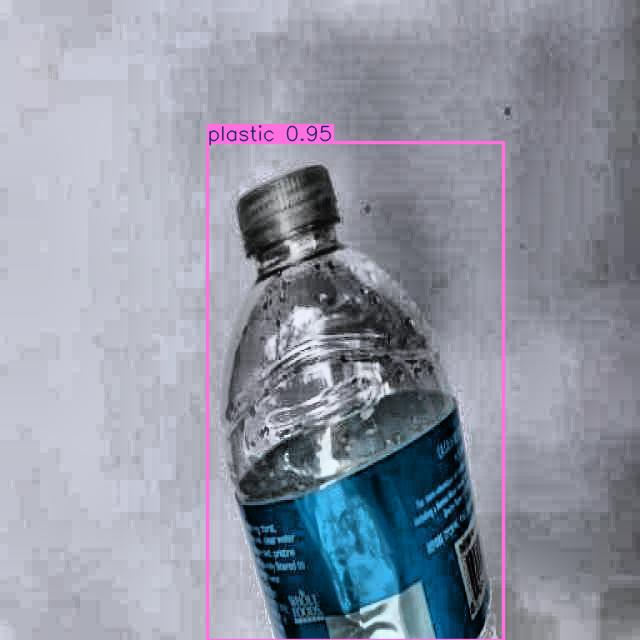

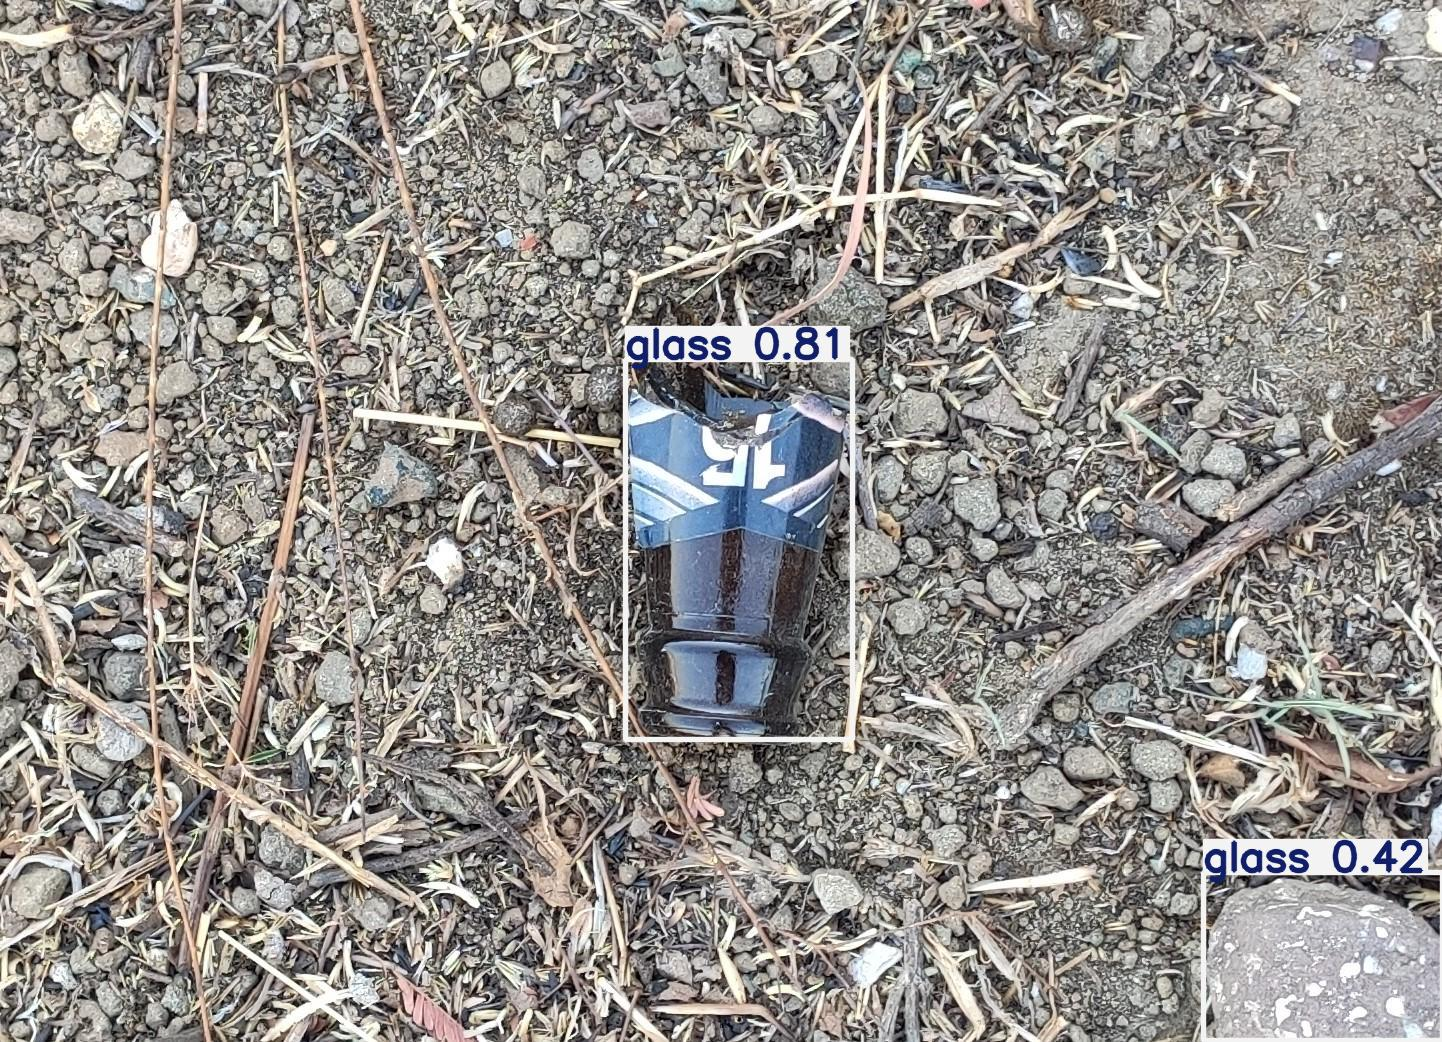

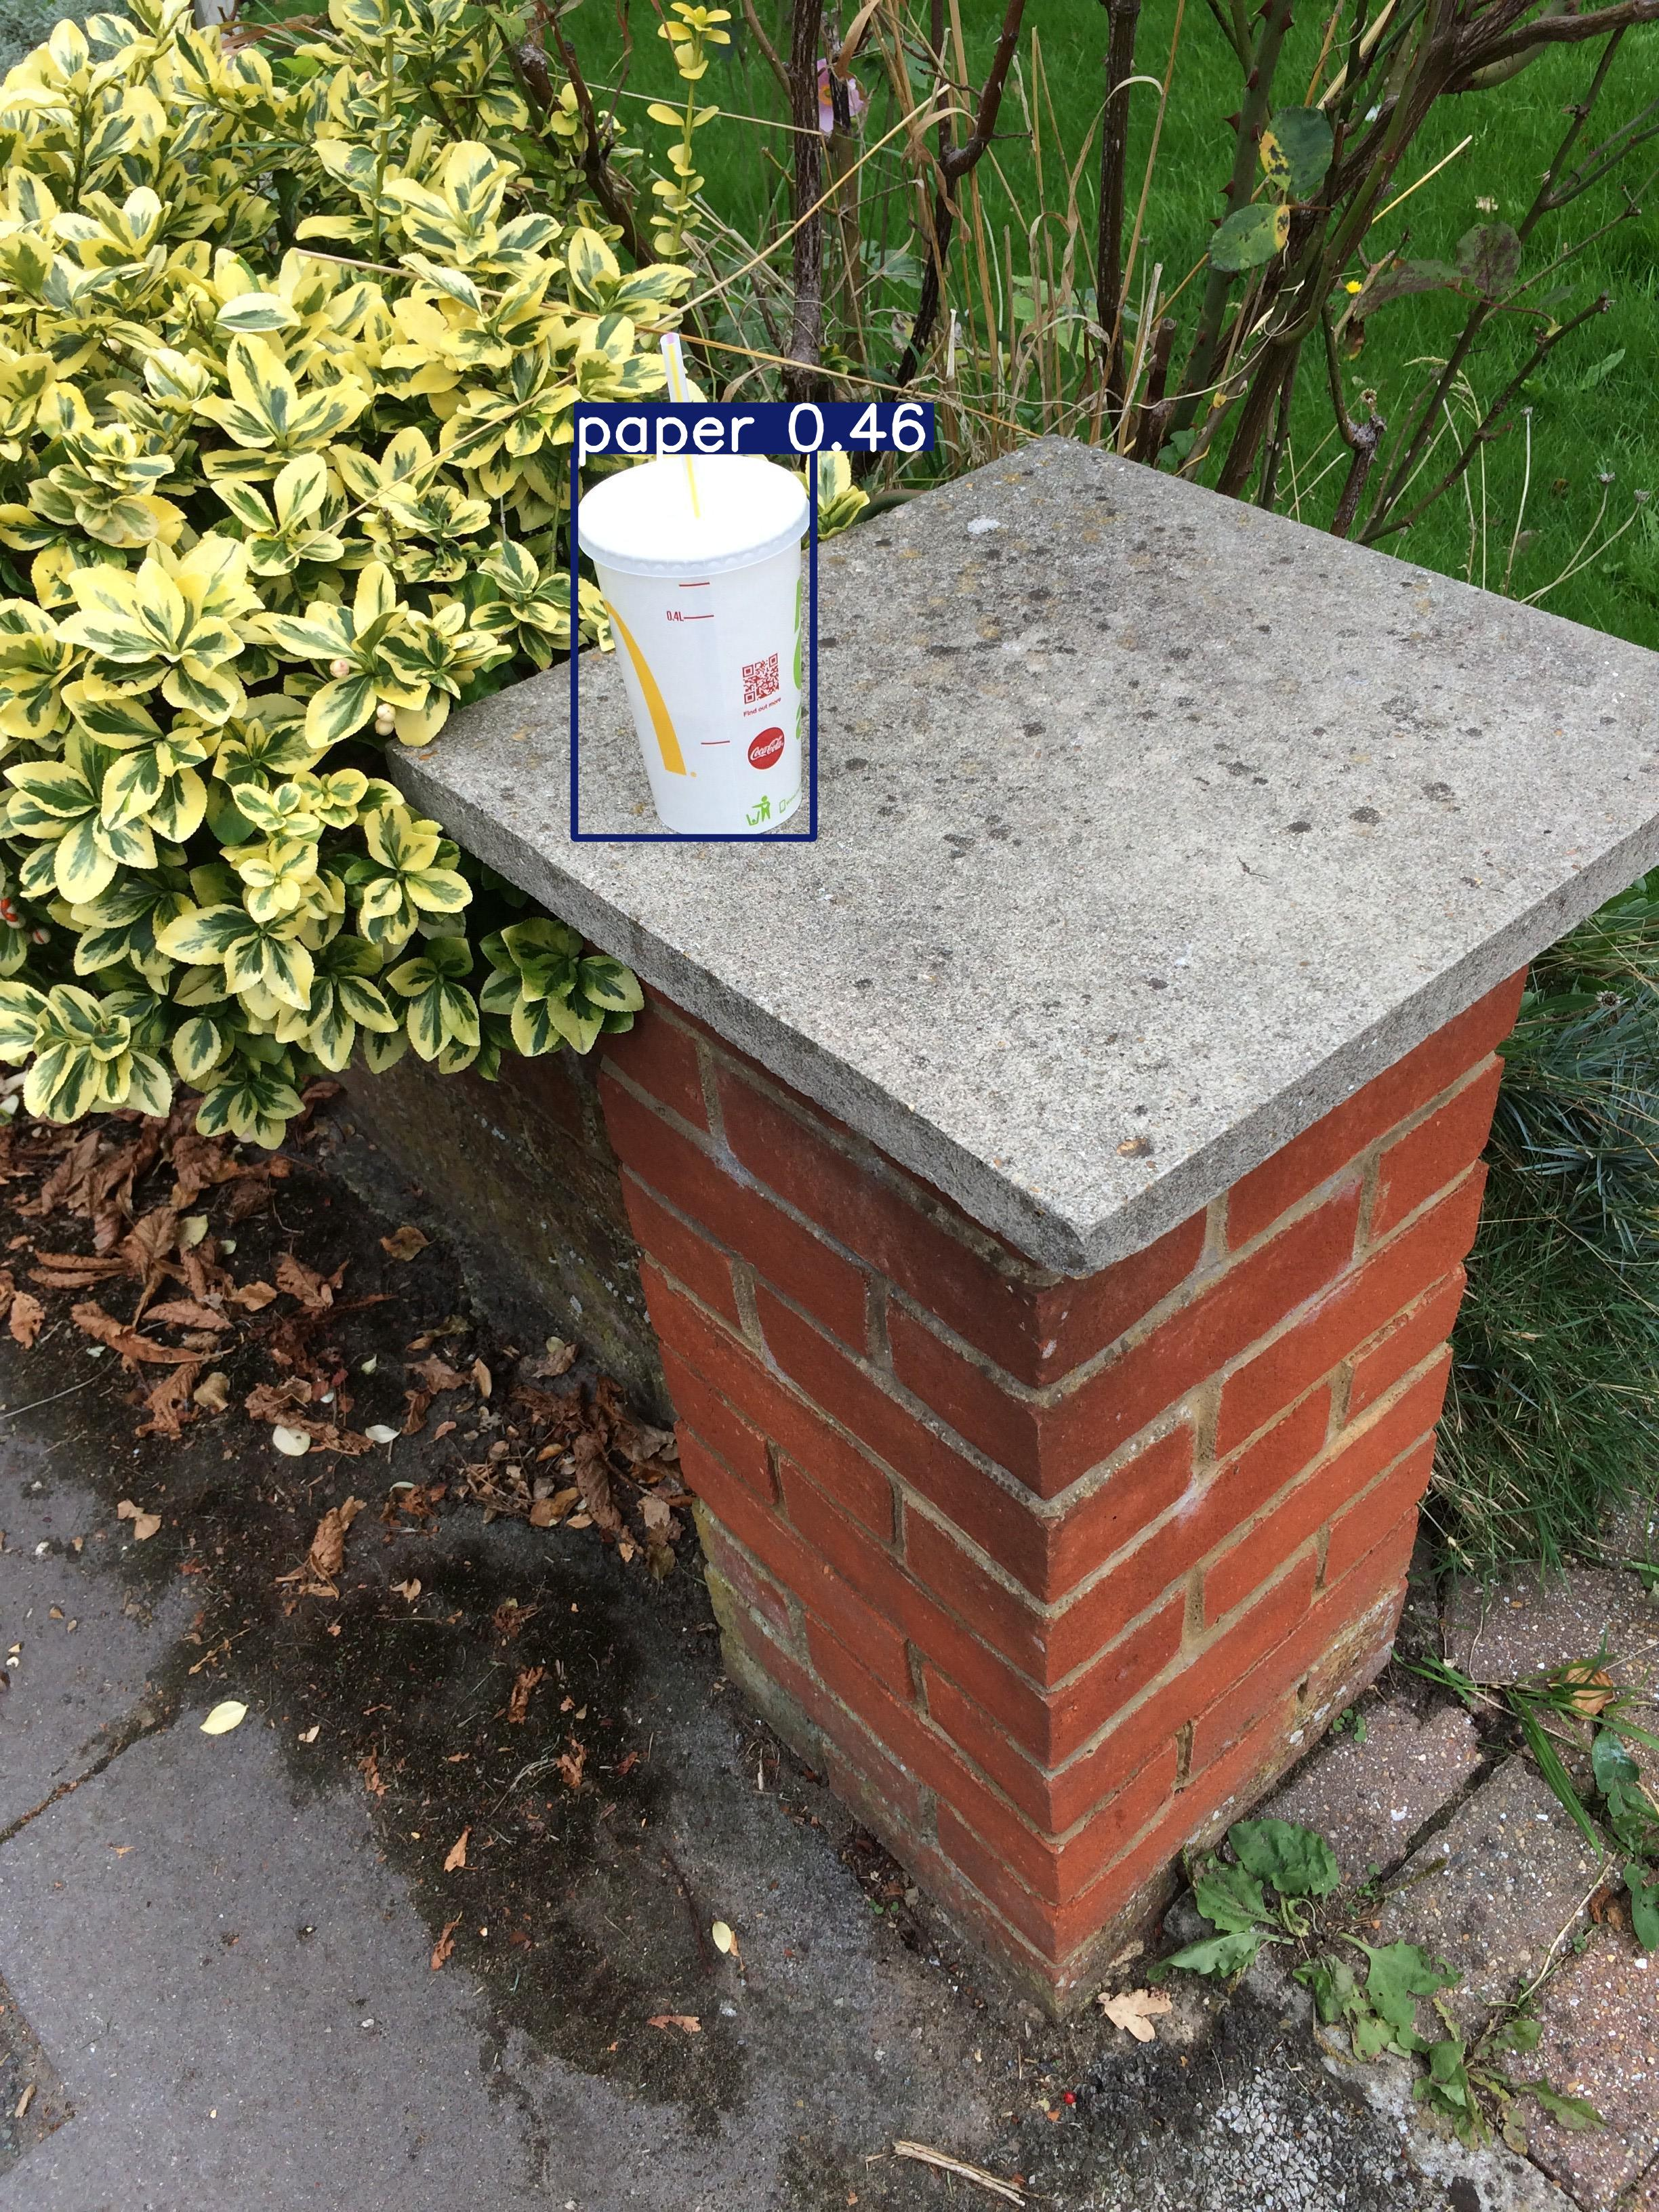

Buffered data was truncated after reaching the output size limit.

In [15]:
results = v1_model(test_images[:10], conf=0.25)

for result in results:
    result.show()
